# Module import

In [1]:
from netCDF4 import Dataset                             
import numpy as np            

import matplotlib.pyplot as plt           
import matplotlib.colors as mcolors              
import cartopy.crs as ccrs                              
import cartopy.feature as cfeature     
import cartopy.io.shapereader as shpreader

import sys
import torch 
import warnings
warnings.filterwarnings("ignore")
from datetime import datetime, timedelta


import os
from scipy.ndimage import gaussian_filter
from matplotlib.colors import ListedColormap

In [2]:
sys.path.append("/home/users/mendrika/Object-Based-LSTMConv/notebooks/model/training")
from pancast import Core2MapModel

# Choose nowcast origin and lead time (in hour)

In [3]:
"/gws/nopw/j04/wiser_ewsa/mrakotomanga/pancast/raw/inputs_t0/input-20231119_1900.pt"
"/work/scratch-nopw2/mendrika/pancast/raw/inputs_t0/input-20220219_0930.pt" # good for Madagascar
"/work/scratch-nopw2/mendrika/pancast/raw/inputs_t0/input-20210212_1500.pt"
"/work/scratch-nopw2/mendrika/pancast/raw/inputs_t0/input-20240120_1530.pt"
"/work/scratch-nopw2/mendrika/pancast/raw/inputs_t0/input-20210715_2000.pt",


('/work/scratch-nopw2/mendrika/pancast/raw/inputs_t0/input-20210715_2000.pt',)

In [4]:
year = "2021"
month = "07"
day = "15"
hour = "20"
minute = "00"

# Ground truth 

In [5]:
def update_hour(date_dict, hours_to_add, minutes_to_add):
    """
    Add hours and minutes to a datetime dictionary and return the updated dict and a generated file path.

    Args:
        date_dict     (dict): Keys: 'year', 'month', 'day', 'hour', 'minute' as strings, e.g. "01", "23"
        hours_to_add   (int): Number of hours to add.
        minutes_to_add (int): Number of minutes to add.

    Returns:
        tuple:
            - dict: Updated datetime dictionary with all fields as zero-padded strings.
            - str: File path in the format YYYY/MM/YYYYMMDDHHMM.nc
    """
    # Parse the original time
    time_obj = datetime(
        int(date_dict["year"]),
        int(date_dict["month"]),
        int(date_dict["day"]),
        int(date_dict["hour"]),
        int(date_dict["minute"])
    )

    # Add hours
    updated = time_obj + timedelta(hours=hours_to_add, minutes=minutes_to_add)

    # Format updated dictionary
    new_date_dict = {
        "year":   f"{updated.year:04d}",
        "month":  f"{updated.month:02d}",
        "day":    f"{updated.day:02d}",
        "hour":   f"{updated.hour:02d}",
        "minute": f"{updated.minute:02d}"
    }

    # Generate file path
    file_path = f"{new_date_dict['year']}/{new_date_dict['month']}/{new_date_dict['year']}{new_date_dict['month']}{new_date_dict['day']}{new_date_dict['hour']}{new_date_dict['minute']}.nc"

    return {'time': new_date_dict, 'path': file_path}

In [6]:
def load_wavelet_dataset(year, month, day, hour, minute, lead_time):
    
    nowcast_origin = {
        "year":   year,
        "month":  month,
        "day":    day,
        "hour":   hour,
        "minute": minute,
    }

    nowcast_lt = update_hour(nowcast_origin, hours_to_add=0, minutes_to_add=lead_time)["time"]

    path_core = f"/gws/nopw/j04/cocoon/SSA_domain/ch9_wavelet/{nowcast_lt['year']}/{nowcast_lt['month']}"
    file = f"{path_core}/{nowcast_lt['year']}{nowcast_lt['month']}{nowcast_lt['day']}{nowcast_lt['hour']}{nowcast_lt['minute']}.nc"
    return Dataset(file, mode='r')["cores"]

In [7]:
y_min, y_max = 48, 2062
x_min, x_max = 81, 2267

In [8]:
ground_truth_t030 = load_wavelet_dataset(year, month, day, hour, minute, 30)[0, y_min:y_max+1, x_min:x_max+1] != 0
ground_truth_t060 = load_wavelet_dataset(year, month, day, hour, minute, 60)[0, y_min:y_max+1, x_min:x_max+1] != 0
ground_truth_t090 = load_wavelet_dataset(year, month, day, hour, minute, 90)[0, y_min:y_max+1, x_min:x_max+1] != 0
ground_truth_t120 = load_wavelet_dataset(year, month, day, hour, minute, 120)[0, y_min:y_max+1, x_min:x_max+1] != 0

In [9]:
geodata = np.load("/gws/nopw/j04/cocoon/SSA_domain/lat_lon_2268_2080.npz")
lons = geodata["lon"][y_min:y_max+1, x_min:x_max+1]
lats = geodata["lat"][y_min:y_max+1, x_min:x_max+1]

In [10]:
def load_zcast_input(year, month, day, hour, minute, lead_time):

    input_paths = [
        "/work/scratch-nopw2/mendrika/pancast/raw/inputs_t0",
        "/gws/nopw/j04/wiser_ewsa/mrakotomanga/pancast/raw/inputs_t0",
    ]

    fname = f"input-{year}{month}{day}_{hour}{minute}.pt"

    for base in input_paths:
        core_input = f"{base}/{fname}"
        if os.path.exists(core_input):
            return torch.load(core_input)

    raise FileNotFoundError(
        f"ZCAST input not found in any known location: {fname}"
    )


In [11]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

In [12]:
ENSEMBLE_DIR_T030 = f"/gws/nopw/j04/wiser_ewsa/mrakotomanga/pancast/final/checkpoints/t030min"
ENSEMBLE_DIR_T060 = f"/gws/nopw/j04/wiser_ewsa/mrakotomanga/pancast/final/checkpoints/t060min"
ENSEMBLE_DIR_T090 = f"/gws/nopw/j04/wiser_ewsa/mrakotomanga/pancast/final/checkpoints/t090min"
ENSEMBLE_DIR_T120 = f"/gws/nopw/j04/wiser_ewsa/mrakotomanga/pancast/final/checkpoints/t120min"

In [13]:
def load_models(ensemble_dir):
    models = []
    for seed in sorted(os.listdir(ensemble_dir)):
        ckpt = os.path.join(ensemble_dir, seed, "lr7e-05/best-pancast.ckpt")
        if os.path.exists(ckpt):
            model = Core2MapModel.load_from_checkpoint(ckpt, map_location=DEVICE)
            model.eval().to(DEVICE)
            models.append(model)
            print(f"Loaded {ckpt}")
    return models

In [14]:
def ensemble_predict(models, x):
    preds = []
    with torch.no_grad():
        for model in models:
            pred = torch.sigmoid(model(x)).squeeze(0).squeeze(0)
            preds.append(pred)
    preds = torch.stack(preds)
    mean_pred = preds.mean(dim=0)
    var_pred  = preds.var(dim=0)
    return mean_pred, var_pred

In [15]:
models_t030 = load_models(ENSEMBLE_DIR_T030)
models_t060 = load_models(ENSEMBLE_DIR_T060)
models_t090 = load_models(ENSEMBLE_DIR_T090)
models_t120 = load_models(ENSEMBLE_DIR_T120)

Loaded /gws/nopw/j04/wiser_ewsa/mrakotomanga/pancast/final/checkpoints/t030min/seed134/lr7e-05/best-pancast.ckpt
Loaded /gws/nopw/j04/wiser_ewsa/mrakotomanga/pancast/final/checkpoints/t030min/seed1998/lr7e-05/best-pancast.ckpt
Loaded /gws/nopw/j04/wiser_ewsa/mrakotomanga/pancast/final/checkpoints/t030min/seed2025/lr7e-05/best-pancast.ckpt
Loaded /gws/nopw/j04/wiser_ewsa/mrakotomanga/pancast/final/checkpoints/t030min/seed40/lr7e-05/best-pancast.ckpt
Loaded /gws/nopw/j04/wiser_ewsa/mrakotomanga/pancast/final/checkpoints/t030min/seed676/lr7e-05/best-pancast.ckpt
Loaded /gws/nopw/j04/wiser_ewsa/mrakotomanga/pancast/final/checkpoints/t060min/seed134/lr7e-05/best-pancast.ckpt
Loaded /gws/nopw/j04/wiser_ewsa/mrakotomanga/pancast/final/checkpoints/t060min/seed1998/lr7e-05/best-pancast.ckpt
Loaded /gws/nopw/j04/wiser_ewsa/mrakotomanga/pancast/final/checkpoints/t060min/seed2025/lr7e-05/best-pancast.ckpt
Loaded /gws/nopw/j04/wiser_ewsa/mrakotomanga/pancast/final/checkpoints/t060min/seed40/lr7e-05

In [16]:
SCALER_PATH = "/home/users/mendrika/Object-Based-LSTMConv/outputs/scaler-africa/scaler_realcores_online.pt"

MASK_COL_INDEX = 12
COLS_TO_SCALE = range(4, 12)

# load scaler
scaler = torch.load(SCALER_PATH, weights_only=False)
mean = np.asarray(scaler["mean"])
scale = np.asarray(scaler["scale"])

In [323]:
zcast_input = load_zcast_input(year, month, day, hour, minute, 0)

input_tensor = zcast_input["input_tensor"].clone().unsqueeze(0)

In [324]:
try:
    # load one instance
    zcast_input = load_zcast_input(year, month, day, hour, minute, 0)

    input_tensor = zcast_input["input_tensor"].clone().unsqueeze(0)

    # remove batch dim for scaling
    X = input_tensor[0]

    # convert to numpy
    X_np = X.numpy()

    flat = X_np.reshape(-1, X_np.shape[-1])

    flat[:, COLS_TO_SCALE] = (flat[:, COLS_TO_SCALE] - mean) / scale

    X_scaled = torch.tensor(flat.reshape(X_np.shape), dtype=torch.float32)

    input_scaled = X_scaled.unsqueeze(0)

    mean_pred_t030, _ = ensemble_predict(models_t030, input_scaled.to(DEVICE))
    mean_pred_t060, _ = ensemble_predict(models_t060, input_scaled.to(DEVICE))
    mean_pred_t090, _ = ensemble_predict(models_t090, input_scaled.to(DEVICE))
    mean_pred_t120, _ = ensemble_predict(models_t120, input_scaled.to(DEVICE))

except:
    print("No data")

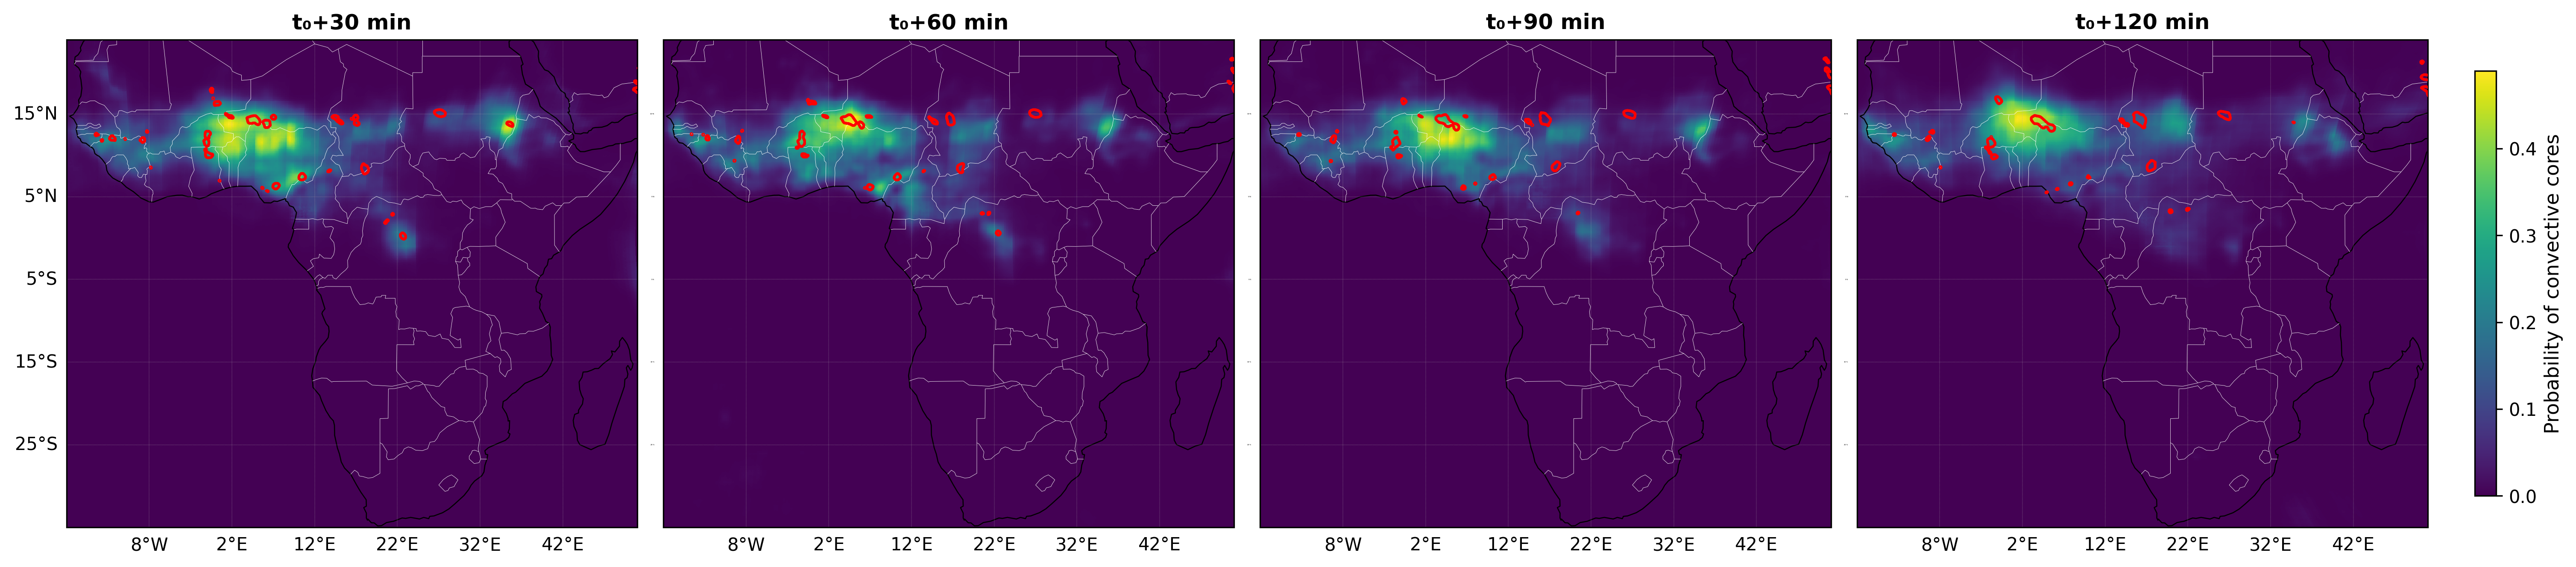

In [325]:
preds = {
    30: mean_pred_t030,
    60: mean_pred_t060,
    90: mean_pred_t090,
    120: mean_pred_t120
}

gts = {
    30: ground_truth_t030,
    60: ground_truth_t060,
    90: ground_truth_t090,
    120: ground_truth_t120
}


fig, axes = plt.subplots(
    1, 4,
    figsize=(20, 6),
    subplot_kw={"projection": ccrs.PlateCarree()},
    dpi=300,
    constrained_layout=True
)

lead_times = [30, 60, 90, 120]
extent = (-18, 51, -35, 24)

for idx, lead_time in enumerate(lead_times):

    ax = axes[idx]

    if idx == 0:
        ax.set_ylabel("Latitude", fontsize=11)
    else:
        ax.set_ylabel("")
        ax.set_yticks([])

    ax.set_title(f"t₀+{lead_time} min", fontsize=12, weight="bold")

    ax.set_extent(extent, crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.LAND, facecolor="white", edgecolor="white", linewidth=0.5)
    ax.add_feature(cfeature.OCEAN, facecolor="lightblue")
    ax.add_feature(cfeature.COASTLINE, edgecolor="black", linewidth=0.6)
    ax.add_feature(cfeature.BORDERS, edgecolor="white", linewidth=0.2)

    gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.1, 
                    xlocs=np.arange(round(extent[0]), round(extent[1]), 10),
                    ylocs=np.arange(round(extent[-2]), round(extent[-1]), 10)
                    )

    gl.top_labels = False
    gl.right_labels = False
    if idx != 0:
        gl.ylabel_style = {"size": 0}

    pred = preds[lead_time]
    gt = gts[lead_time]

    masked = np.ma.masked_where(pred <= 0, pred)

    im = ax.pcolormesh(
        lons, lats, masked.squeeze(),
        cmap="viridis",
        vmin=0,
        vmax=np.max(masked),
        transform=ccrs.PlateCarree(),
        zorder=1
    )

    gt_s = gaussian_filter(gt.astype(float), sigma=0.4)

    ax.contour(
        lons, lats, gt_s,
        levels=[0.5],
        colors="red",
        linewidths=1.5,
        transform=ccrs.PlateCarree(),
        zorder=5
    )


cbar = fig.colorbar(
    im,
    ax=axes,
    orientation="vertical",
    fraction=0.009,
    pad=0.02
)
cbar.set_label("Probability of convective cores", fontsize=11)

plt.show()

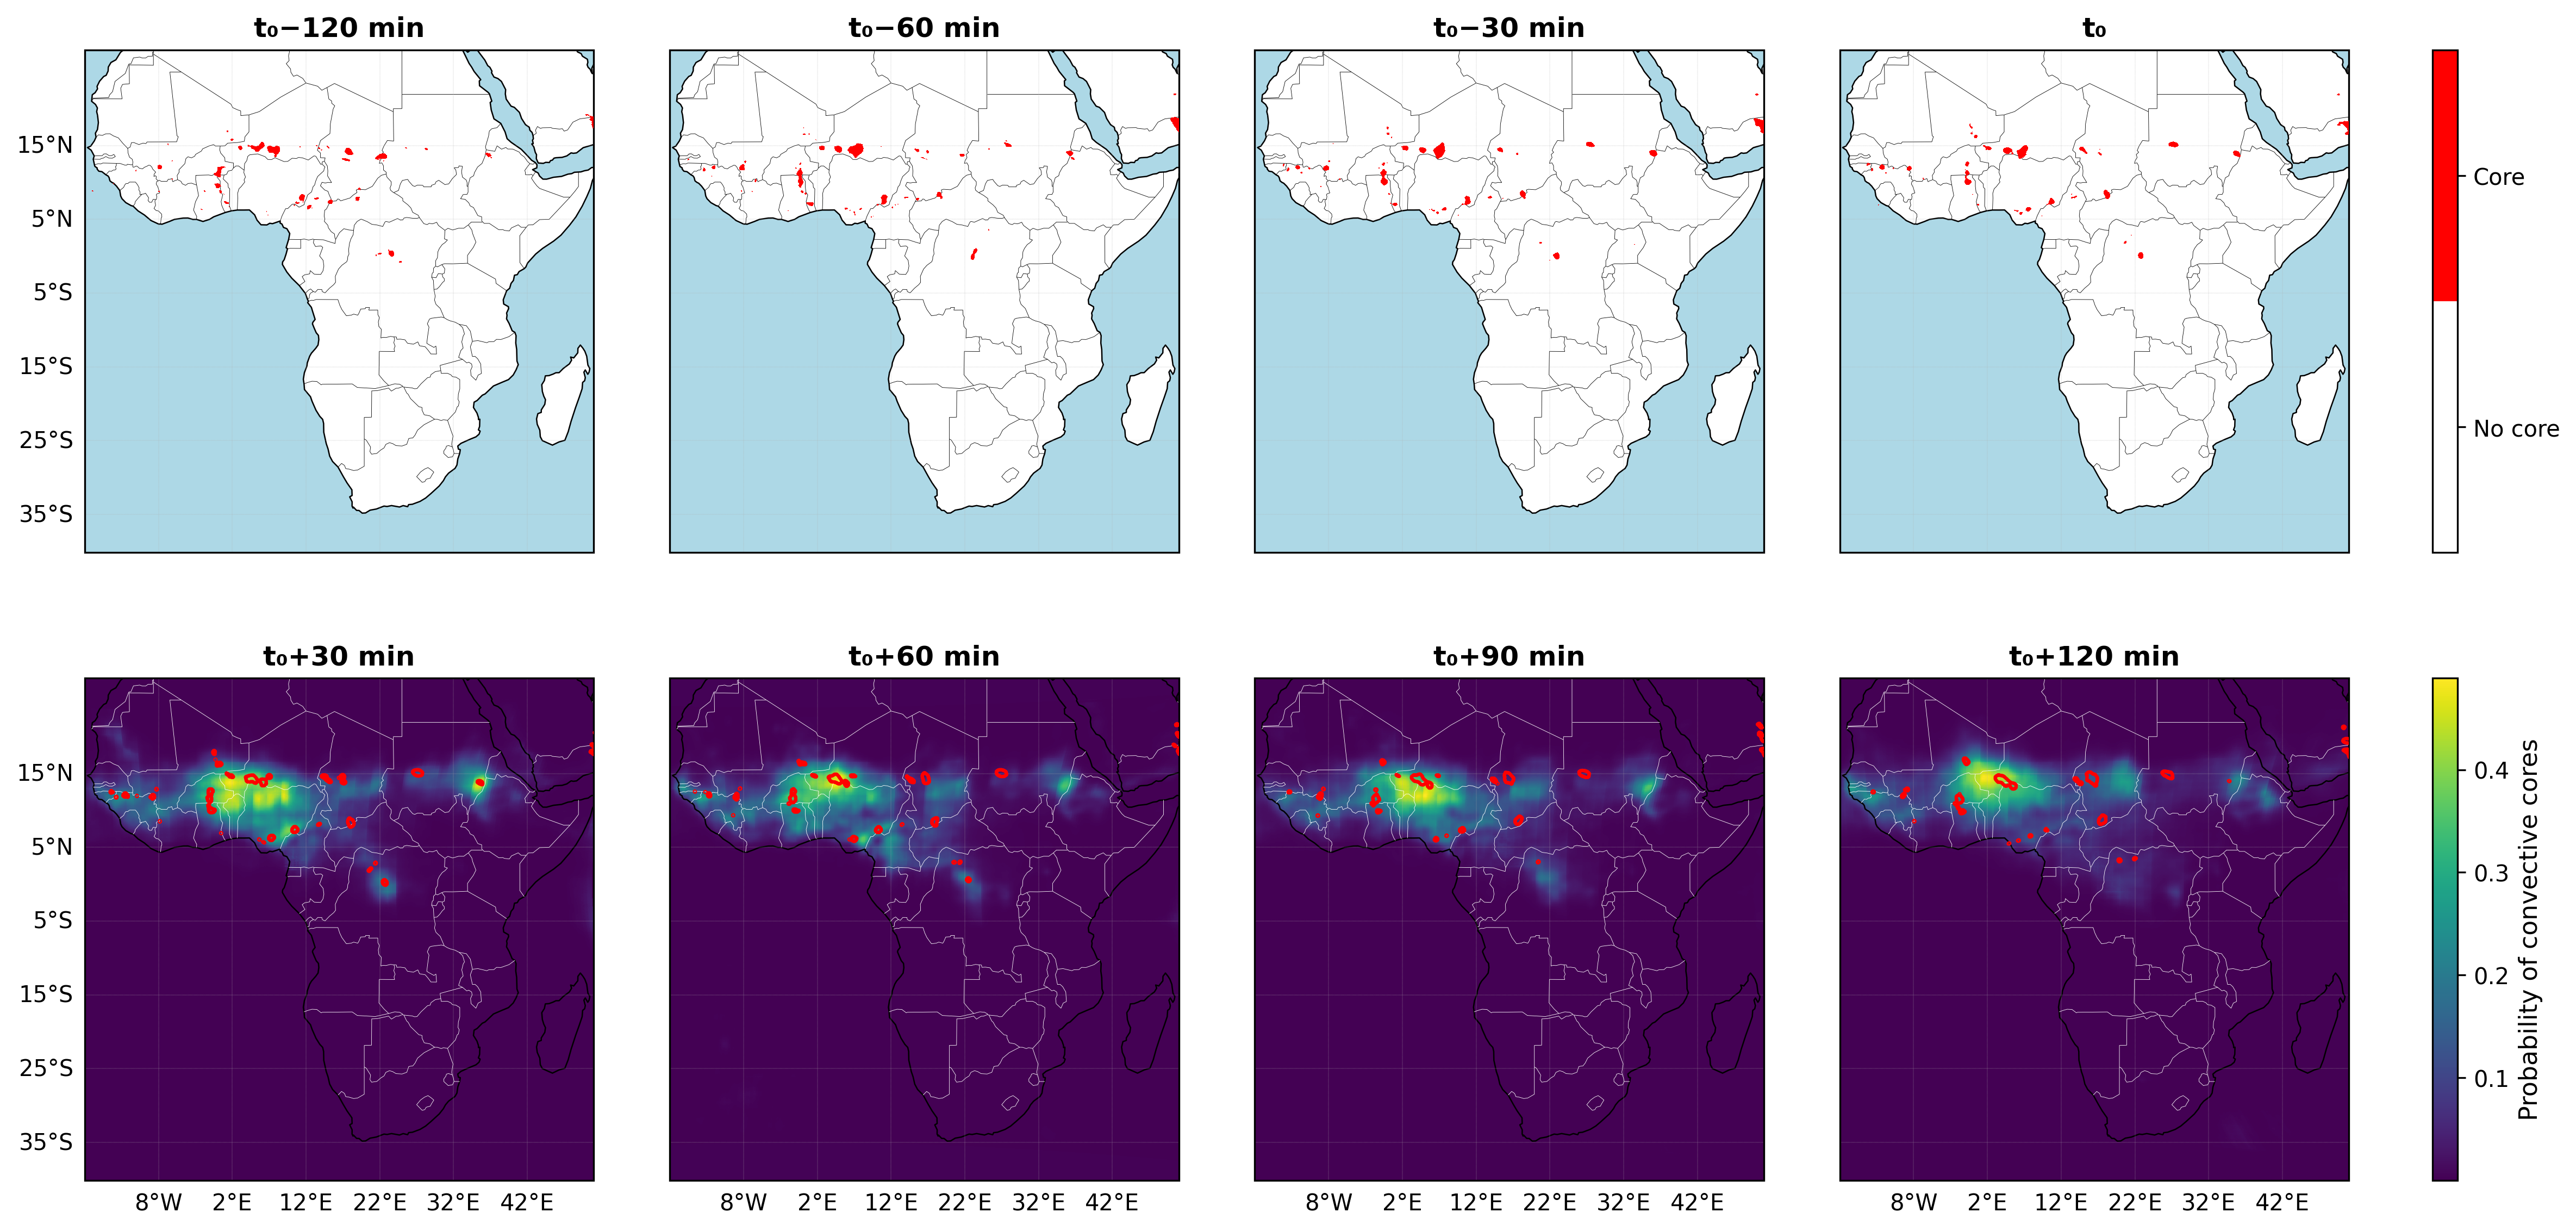

In [326]:
inputs = {
    "t₀−120 min": load_wavelet_dataset(year, month, day, hour, minute, -120)[0, y_min:y_max+1, x_min:x_max+1] != 0,
    "t₀−60 min":  load_wavelet_dataset(year, month, day, hour, minute,  -60)[0, y_min:y_max+1, x_min:x_max+1] != 0,
    "t₀−30 min":  load_wavelet_dataset(year, month, day, hour, minute,  -30)[0, y_min:y_max+1, x_min:x_max+1] != 0,
    "t₀":         load_wavelet_dataset(year, month, day, hour, minute,    0)[0, y_min:y_max+1, x_min:x_max+1] != 0,
}


fig, axes = plt.subplots(
    2, 4,
    figsize=(22, 9),
    subplot_kw={"projection": ccrs.PlateCarree()},
    dpi=300,
    constrained_layout=False
)

fig.subplots_adjust(wspace=-0.35, hspace=0.25)

frame_cmap = ListedColormap([
    (1, 0, 0, 0),  # 0 -> transparent
    (1, 0, 0, 1),  # 1 -> red
])

im_mask = None

for ax, (title, mask) in zip(axes[0], inputs.items()):

    ax.set_title(title, fontsize=12, weight="bold")
    ax.set_ylabel("")

    ax.set_extent(extent)

    ax.add_feature(cfeature.LAND, facecolor="white", edgecolor="white", linewidth=0.5)
    ax.add_feature(cfeature.OCEAN, facecolor="lightblue")
    ax.add_feature(cfeature.COASTLINE, edgecolor="black", linewidth=0.6)
    ax.add_feature(cfeature.BORDERS, edgecolor="black", linewidth=0.2)

    gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.1, 
                    xlocs=np.arange(round(extent[0]), round(extent[1]), 10),
                    ylocs=np.arange(round(extent[-2]), round(extent[-1]), 10)
                    )

    gl.top_labels = False
    gl.right_labels = False
    gl.bottom_labels = False

    if ax is not axes[0][0]:
        gl.left_labels = False

    display = mask.astype(int)

    im_mask = ax.pcolormesh(
        lons,
        lats,
        display,
        cmap=frame_cmap,
        vmin=0,
        vmax=1,
        transform=ccrs.PlateCarree(),
        zorder=5,
    )

# colourbar for TOP row only
cbar_mask = fig.colorbar(
    im_mask,
    ax=axes[0, :],
    orientation="vertical",
    fraction=0.015,
    pad=0.03
)
cbar_mask.set_ticks([0.25, 0.75])
cbar_mask.set_ticklabels(["No core", "Core"])

for idx, lead_time in enumerate([30, 60, 90, 120]):

    ax = axes[1, idx]

    if idx == 0:
        ax.set_ylabel("Latitude", fontsize=11)
    else:
        ax.set_ylabel("")
        ax.set_yticks([])

    ax.set_title(f"t₀+{lead_time} min", fontsize=12, weight="bold")

    ax.set_extent(extent)

    ax.add_feature(cfeature.LAND, facecolor="white", edgecolor="white", linewidth=0.5)
    ax.add_feature(cfeature.OCEAN, facecolor="lightblue")
    ax.add_feature(cfeature.COASTLINE, edgecolor="black", linewidth=0.6)
    ax.add_feature(cfeature.BORDERS, edgecolor="white", linewidth=0.2)

    gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.1, 
                    xlocs=np.arange(round(extent[0]), round(extent[1]), 10),
                    ylocs=np.arange(round(extent[-2]), round(extent[-1]), 10)
                    )
    gl.top_labels = False
    gl.right_labels = False
    gl.bottom_labels = True

    if idx != 0:
        gl.left_labels = False

    pred = preds[lead_time]
    gt = gts[lead_time]

    masked = np.ma.masked_where(pred <= 0, pred)

    im = ax.pcolormesh(
        lons,
        lats,
        masked.squeeze(),
        cmap="viridis",
        vmin=masked.min(),
        vmax=masked.max(),
        transform=ccrs.PlateCarree(),
        zorder=1
    )

    gt_s = gaussian_filter(gt.astype(float), sigma=0.4)

    ax.contour(
        lons,
        lats,
        gt_s,
        levels=[0.5],
        colors="red",
        linewidths=1.5,
        transform=ccrs.PlateCarree(),
        zorder=5
    )

# colourbar for BOTTOM row only
cbar = fig.colorbar(
    im,
    ax=axes[1, :],
    orientation="vertical",
    fraction=0.015,
    pad=0.03
)
cbar.set_label("Probability of convective cores", fontsize=11)

plt.show()

In [327]:
print(f"pancast-{year}{month}{day}_{hour}{minute}.png")

pancast-20210715_2000.png
